Create paths and retrieve data

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [28]:
factors = pd.read_excel("project Factors_2026.xlsx")
stocks = pd.read_excel("project Stocks_2026.xlsx")
funds = pd.read_excel("project Funds_2026.xlsx")

1.)

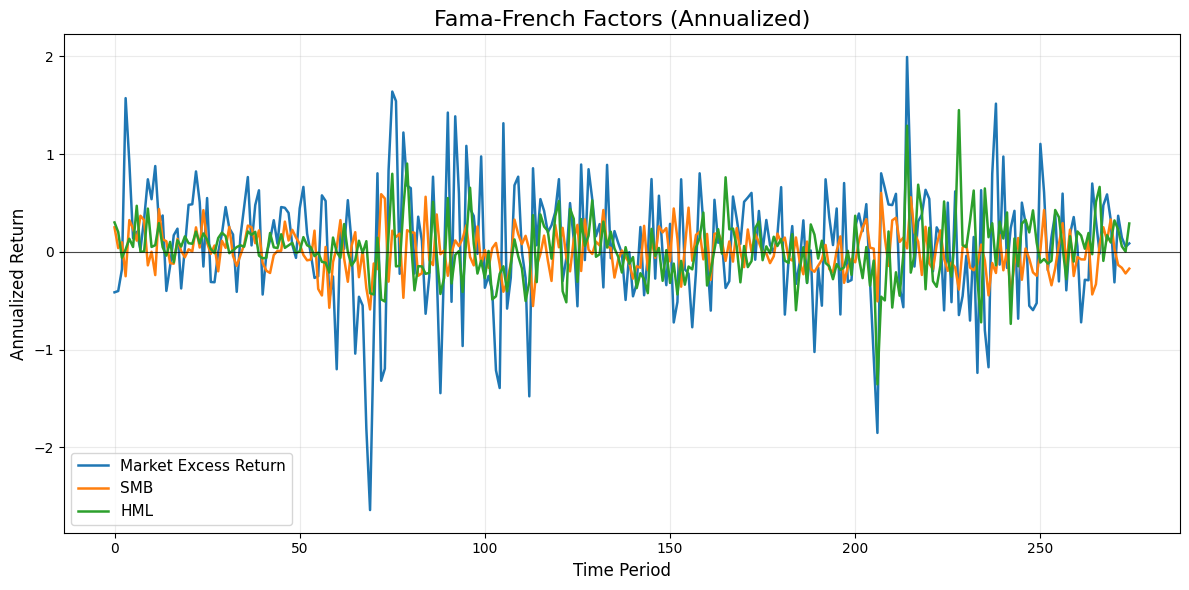

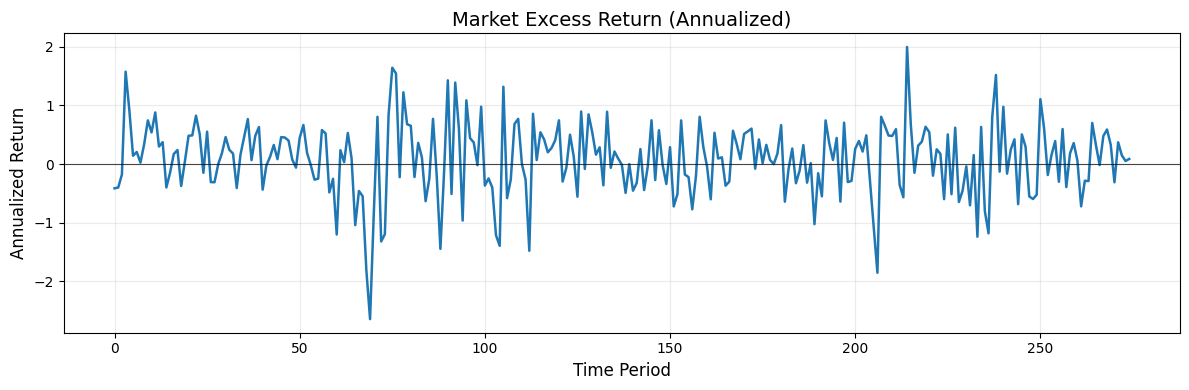

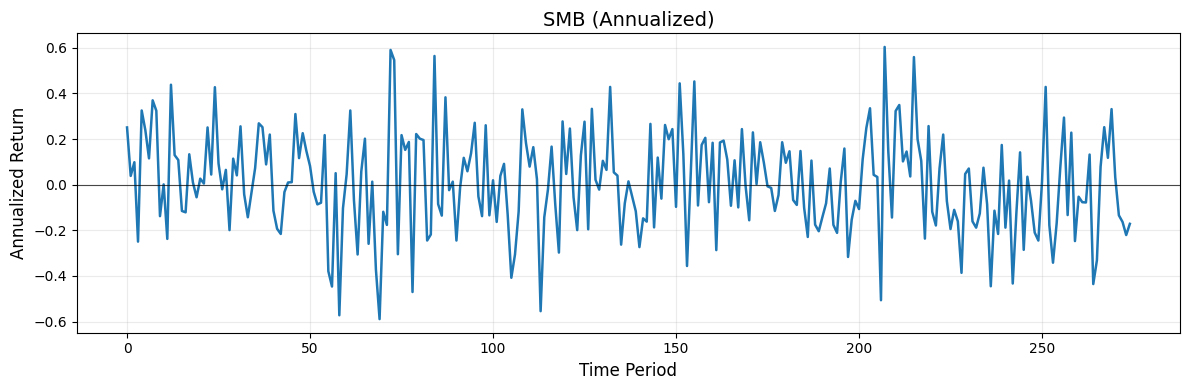

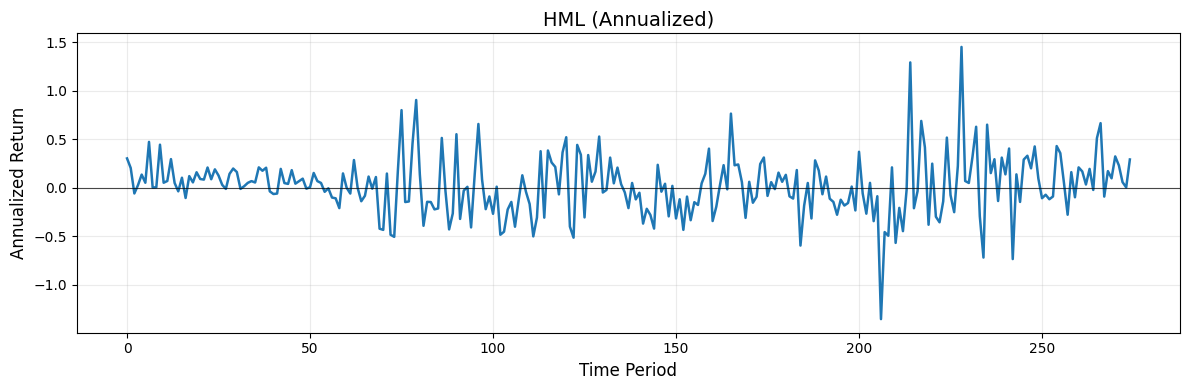

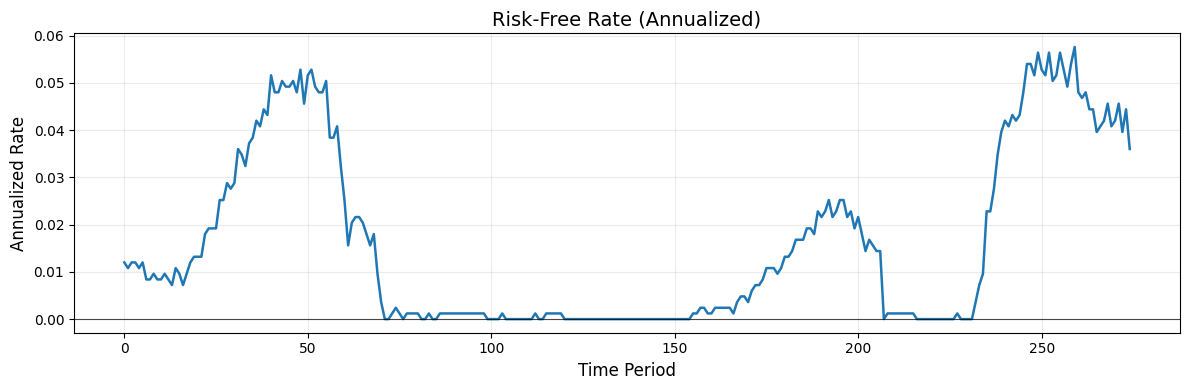

,Mean
rm_rf,0.0841
smb_vw,0.0087
hml_vw,0.0218


,rf_mean
0,0.0161


,rm_rf,smb_vw,hml_vw,rf
rm_rf,0.3844,0.0078,0.0629,0.0001
smb_vw,0.0078,0.0478,-0.0055,-0.0006
hml_vw,0.0629,-0.0055,0.0943,0.0006
rf,0.0001,-0.0006,0.0006,0.0003


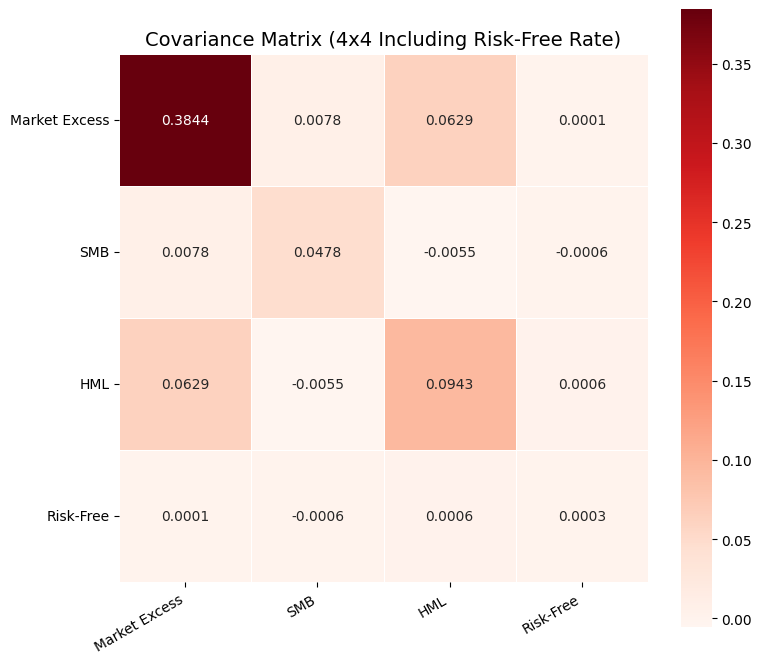

In [30]:
factors_q1 = factors.copy()
stocks_q1 = stocks.copy()

factors_q1[['rm_rf','smb_vw','hml_vw','rf']] *= 12
stocks_q1.iloc[:,3:] *= 12

plt.figure(figsize=(12,6))
plt.plot(factors_q1.index, factors_q1['rm_rf'], label='Market Excess Return', linewidth=1.8)
plt.plot(factors_q1.index, factors_q1['smb_vw'], label='SMB', linewidth=1.8)
plt.plot(factors_q1.index, factors_q1['hml_vw'], label='HML', linewidth=1.8)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.7)
plt.title("Fama-French Factors (Annualized)", fontsize=16)
plt.xlabel("Time Period", fontsize=12)
plt.ylabel("Annualized Return", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(factors_q1.index, factors_q1['rm_rf'], linewidth=1.8)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.7)
plt.title("Market Excess Return (Annualized)", fontsize=14)
plt.xlabel("Time Period", fontsize=12)
plt.ylabel("Annualized Return", fontsize=12)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(factors_q1.index, factors_q1['smb_vw'], linewidth=1.8)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.7)
plt.title("SMB (Annualized)", fontsize=14)
plt.xlabel("Time Period", fontsize=12)
plt.ylabel("Annualized Return", fontsize=12)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(factors_q1.index, factors_q1['hml_vw'], linewidth=1.8)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.7)
plt.title("HML (Annualized)", fontsize=14)
plt.xlabel("Time Period", fontsize=12)
plt.ylabel("Annualized Return", fontsize=12)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(factors_q1.index, factors_q1['rf'], linewidth=1.8)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.7)
plt.title("Risk-Free Rate (Annualized)", fontsize=14)
plt.xlabel("Time Period", fontsize=12)
plt.ylabel("Annualized Rate", fontsize=12)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

display(factors_q1[['rm_rf','smb_vw','hml_vw']].mean().round(4).to_frame("Mean"))
display(pd.DataFrame({"rf_mean": [round(factors_q1['rf'].mean(), 4)]}))

cov4 = factors_q1[['rm_rf','smb_vw','hml_vw','rf']].cov()
display(cov4.round(4))

import seaborn as sns

cov4_plot = cov4.copy()
cov4_plot.index = ['Market Excess', 'SMB', 'HML', 'Risk-Free']
cov4_plot.columns = ['Market Excess', 'SMB', 'HML', 'Risk-Free']

plt.figure(figsize=(8,7))
sns.heatmap(
    cov4_plot.round(4),
    annot=True,
    fmt=".4f",
    cmap="Reds",
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar=True,
    annot_kws={"size":10}
)
plt.title("Covariance Matrix (4x4 Including Risk-Free Rate)", fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

2.)

,rf,market_mean,market_std
0,0.0013,0.0084,0.0517


,Group,N,Avg return (mean of means),Avg std,Median return,Median std
0,Stocks,49,0.0172,0.0961,0.0145,0.0870
1,Funds,10,0.0083,0.0482,0.0079,0.0482


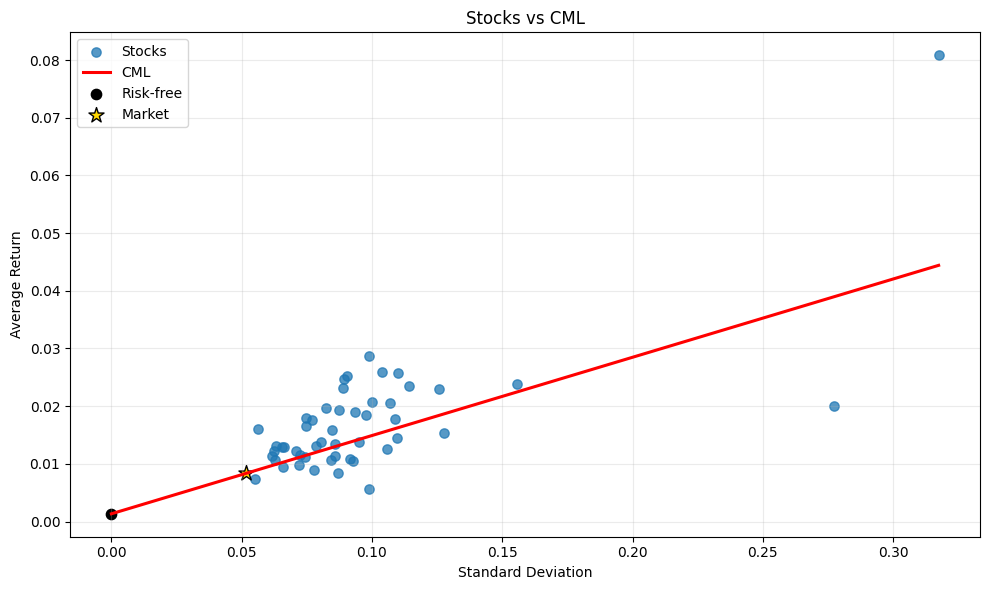

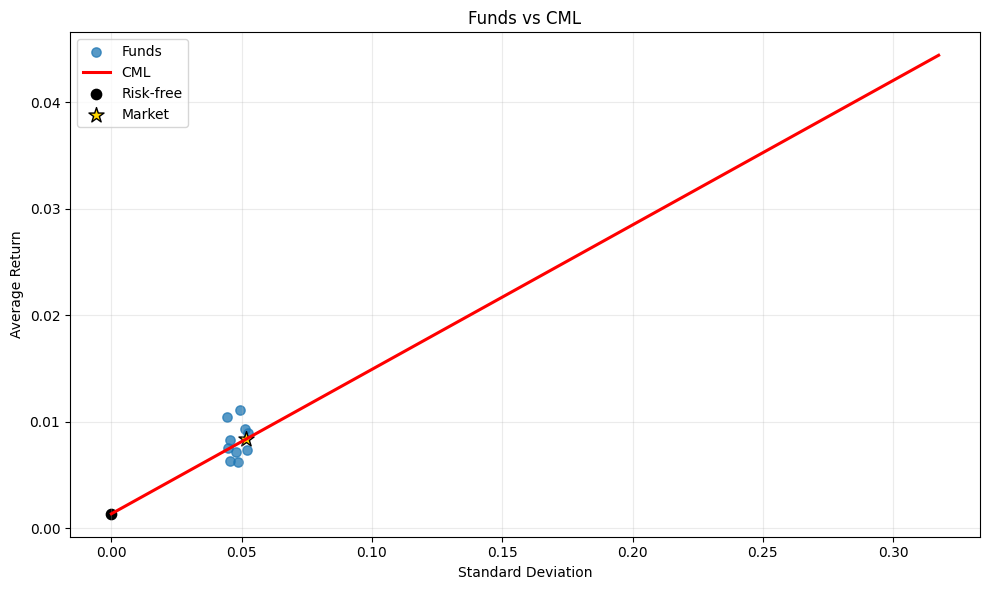

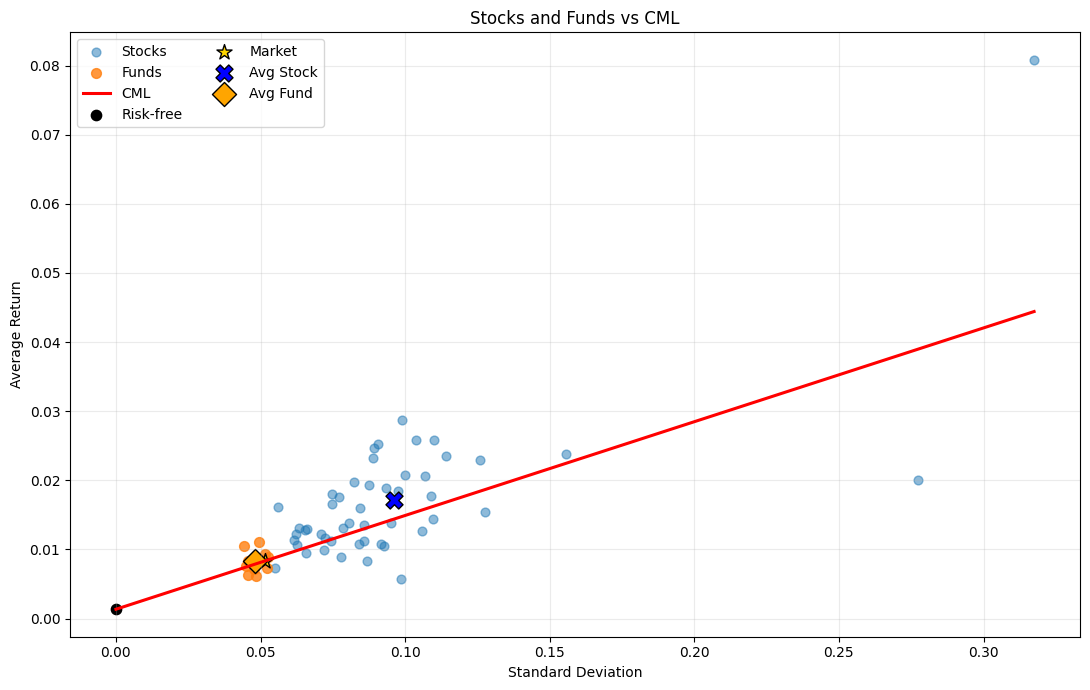

,Group,Above CML,Total
0,Stocks,33,49
1,Funds,6,10


In [34]:
fund_returns = pd.read_excel("project Funds_2026.xlsx", sheet_name="Net")

stock_means = stocks.iloc[:,3:].mean()
stock_std = stocks.iloc[:,3:].std()

fund_panel = fund_returns.iloc[:,3:].apply(pd.to_numeric, errors='coerce')
fund_means = fund_panel.mean()
fund_std = fund_panel.std()

rf = factors['rf'].mean()
market_mean = factors['rm_rf'].mean() + rf
market_std = factors['rm_rf'].std()

x_max = max(stock_std.max(), fund_std.max())
x = np.linspace(0, x_max, 100)
cml = rf + (market_mean - rf) / market_std * x

summary_q2 = pd.DataFrame({
    'Group': ['Stocks', 'Funds'],
    'N': [len(stock_means), len(fund_means)],
    'Avg return (mean of means)': [stock_means.mean(), fund_means.mean()],
    'Avg std': [stock_std.mean(), fund_std.mean()],
    'Median return': [stock_means.median(), fund_means.median()],
    'Median std': [stock_std.median(), fund_std.median()]
})

display(pd.DataFrame({
    "rf": [rf],
    "market_mean": [market_mean],
    "market_std": [market_std]
}).round(4))

display(summary_q2.style.format({
    'Avg return (mean of means)': '{:.4f}',
    'Avg std': '{:.4f}',
    'Median return': '{:.4f}',
    'Median std': '{:.4f}'
}))

plt.figure(figsize=(10,6))
plt.scatter(stock_std, stock_means, alpha=0.75, s=45, label='Stocks')
plt.plot(x, cml, color='red', linewidth=2.2, label='CML')
plt.scatter([0], [rf], color='black', s=55, label='Risk-free')
plt.scatter([market_std], [market_mean], color='gold', edgecolor='black', s=130, marker='*', label='Market')
plt.xlabel("Standard Deviation")
plt.ylabel("Average Return")
plt.title("Stocks vs CML")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
plt.scatter(fund_std, fund_means, alpha=0.75, s=45, label='Funds')
plt.plot(x, cml, color='red', linewidth=2.2, label='CML')
plt.scatter([0], [rf], color='black', s=55, label='Risk-free')
plt.scatter([market_std], [market_mean], color='gold', edgecolor='black', s=130, marker='*', label='Market')
plt.xlabel("Standard Deviation")
plt.ylabel("Average Return")
plt.title("Funds vs CML")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(11,7))
plt.scatter(stock_std, stock_means, alpha=0.50, s=40, label='Stocks')
plt.scatter(fund_std, fund_means, alpha=0.80, s=50, label='Funds')
plt.plot(x, cml, color='red', linewidth=2.2, label='CML')
plt.scatter([0], [rf], color='black', s=55, label='Risk-free')
plt.scatter([market_std], [market_mean], color='gold', edgecolor='black', s=130, marker='*', label='Market')
plt.scatter([stock_std.mean()], [stock_means.mean()], color='blue', edgecolor='black', s=150, marker='X', label='Avg Stock')
plt.scatter([fund_std.mean()], [fund_means.mean()], color='orange', edgecolor='black', s=150, marker='D', label='Avg Fund')
plt.xlabel("Standard Deviation")
plt.ylabel("Average Return")
plt.title("Stocks and Funds vs CML")
plt.grid(True, alpha=0.25)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

stock_cml_at_sigma = rf + (market_mean - rf)/market_std * stock_std
fund_cml_at_sigma = rf + (market_mean - rf)/market_std * fund_std

display(pd.DataFrame({
    "Group": ["Stocks", "Funds"],
    "Above CML": [(stock_means > stock_cml_at_sigma).sum(), (fund_means > fund_cml_at_sigma).sum()],
    "Total": [len(stock_means), len(fund_means)]
}))

3.)

,Mean
rf,0.0013
rm_rf,0.0070
smb_vw,0.0007
hml_vw,0.0018


,beta_CAPM,betaM_FF3,betaSMB,betaHML,E[R]_CAPM,E[R]_FF3,Diff_FF3_minus_CAPM_pp
Stock,,,,,,,
Copperstone Resources AB B,0.3508,0.3889,2.1452,-0.4121,0.0038,0.0049,0.1065
Bergman & Beving AB B,0.9544,0.9024,1.5904,0.1076,0.0080,0.0090,0.0979
Avanza Bank Holding AB,0.7945,0.7866,1.6603,-0.1682,0.0069,0.0077,0.0837
NOTE AB,0.9481,0.9477,1.3128,-0.1916,0.0080,0.0086,0.0596
RaySearch Laboratories AB B,0.9278,0.9548,1.3420,-0.3381,0.0078,0.0084,0.0543
Orron Energy AB,0.9483,0.9661,1.2285,-0.2679,0.0080,0.0085,0.0524
SEB AB A,0.9413,0.8256,0.0370,0.6953,0.0079,0.0084,0.0481
ITAB Shop Concept AB,0.8081,0.8729,1.5448,-0.6150,0.0070,0.0075,0.0450
Swedbank AB A,1.0438,0.9212,-0.1416,0.7601,0.0087,0.0091,0.0422


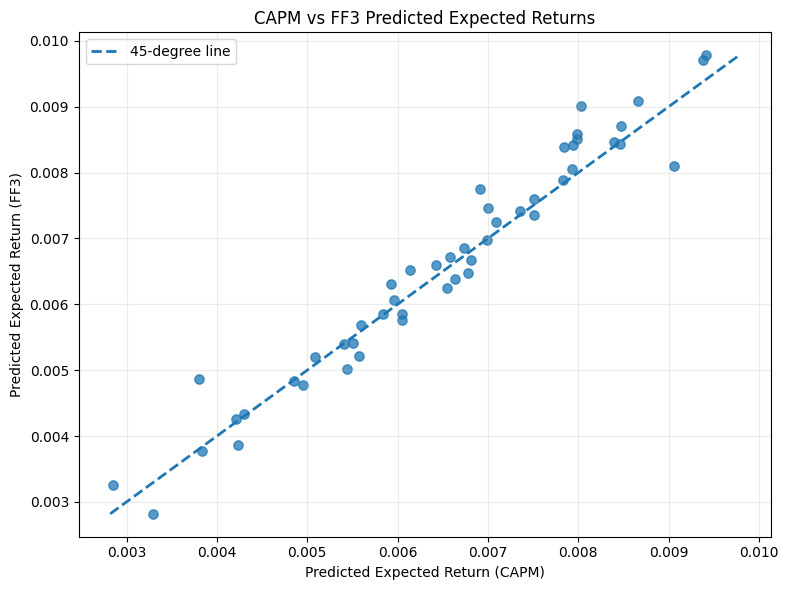

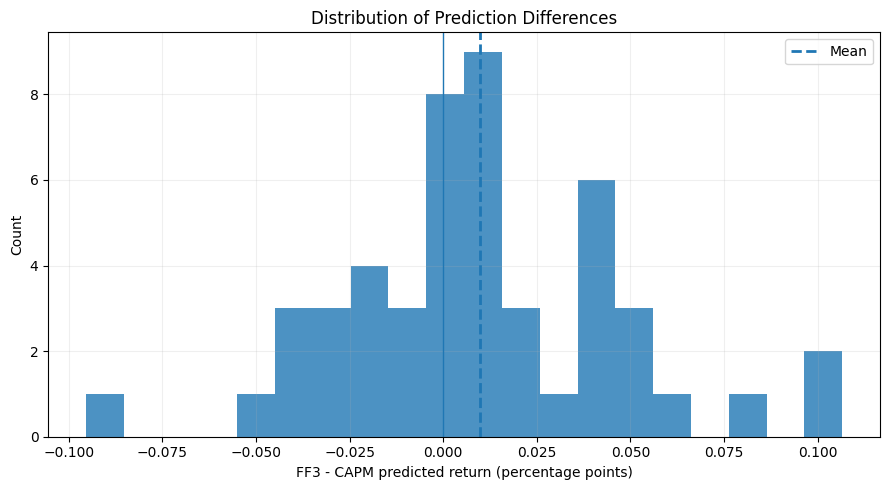

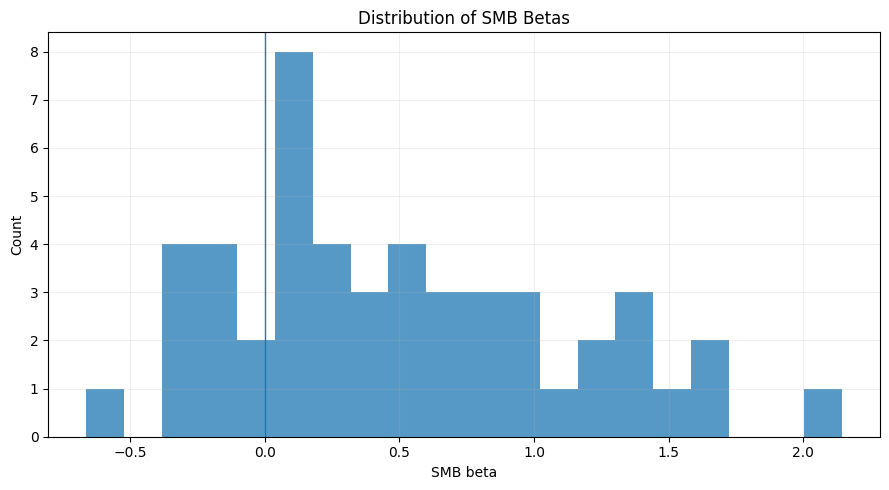

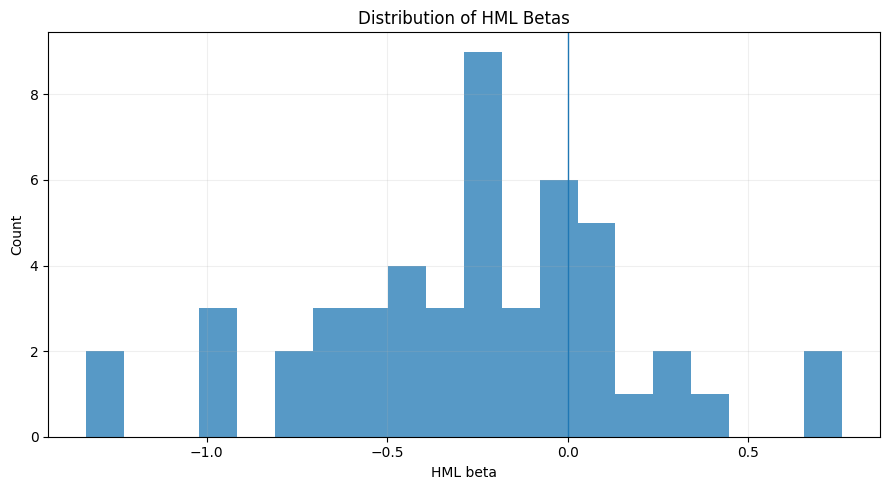

In [33]:
R = stocks.iloc[:,3:].apply(pd.to_numeric, errors="coerce")

rf = pd.to_numeric(factors["rf"], errors="coerce")
m  = pd.to_numeric(factors["rm_rf"], errors="coerce")
s  = pd.to_numeric(factors["smb_vw"], errors="coerce")
h  = pd.to_numeric(factors["hml_vw"], errors="coerce")

n = min(len(R), len(factors))
R = R.iloc[:n].copy()
rf = rf.iloc[:n].reset_index(drop=True)
m  = m.iloc[:n].reset_index(drop=True)
s  = s.iloc[:n].reset_index(drop=True)
h  = h.iloc[:n].reset_index(drop=True)

mu_rf, mu_m, mu_s, mu_h = rf.mean(), m.mean(), s.mean(), h.mean()

X_capm = sm.add_constant(m.rename("rm_rf"))
X_ff3 = sm.add_constant(pd.DataFrame({"rm_rf": m, "smb_vw": s, "hml_vw": h}))

rows = []
for col in R.columns:
    r_i = pd.to_numeric(R[col], errors="coerce").reset_index(drop=True)
    y = r_i - rf

    capm = sm.OLS(y, X_capm, missing="drop").fit()
    ff3  = sm.OLS(y, X_ff3, missing="drop").fit()

    b_capm = capm.params.get("rm_rf", np.nan)
    b_m3   = ff3.params.get("rm_rf", np.nan)
    b_s3   = ff3.params.get("smb_vw", np.nan)
    b_h3   = ff3.params.get("hml_vw", np.nan)

    er_capm = mu_rf + b_capm * mu_m
    er_ff3  = mu_rf + b_m3 * mu_m + b_s3 * mu_s + b_h3 * mu_h

    rows.append([
        col,
        capm.params.get("const", np.nan), b_capm,
        ff3.params.get("const", np.nan), b_m3, b_s3, b_h3,
        er_capm, er_ff3,
        r_i.mean(),
        capm.rsquared, ff3.rsquared
    ])

results = pd.DataFrame(rows, columns=[
    "Stock","alpha_CAPM","beta_CAPM","alpha_FF3","betaM_FF3","betaSMB","betaHML",
    "E[R]_CAPM","E[R]_FF3","Actual_Avg_Return","R2_CAPM","R2_FF3"
]).set_index("Stock")

results["Diff_FF3_minus_CAPM"] = results["E[R]_FF3"] - results["E[R]_CAPM"]
results["Diff_FF3_minus_CAPM_pp"] = 100 * results["Diff_FF3_minus_CAPM"]

display(pd.Series({"rf": mu_rf, "rm_rf": mu_m, "smb_vw": mu_s, "hml_vw": mu_h}).round(4).to_frame("Mean"))

display(
    results[["beta_CAPM","betaM_FF3","betaSMB","betaHML","E[R]_CAPM","E[R]_FF3","Diff_FF3_minus_CAPM_pp"]]
    .sort_values("Diff_FF3_minus_CAPM_pp", ascending=False)
    .style.format("{:.4f}")
)

plt.figure(figsize=(8,6))
plt.scatter(results["E[R]_CAPM"], results["E[R]_FF3"], alpha=0.75, s=45)
xmin = min(results["E[R]_CAPM"].min(), results["E[R]_FF3"].min())
xmax = max(results["E[R]_CAPM"].max(), results["E[R]_FF3"].max())
plt.plot([xmin, xmax], [xmin, xmax], linestyle="--", linewidth=2, label="45-degree line")
plt.xlabel("Predicted Expected Return (CAPM)")
plt.ylabel("Predicted Expected Return (FF3)")
plt.title("CAPM vs FF3 Predicted Expected Returns")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,5))
plt.hist(results["Diff_FF3_minus_CAPM_pp"].dropna(), bins=20, alpha=0.8)
plt.axvline(0, linewidth=1)
plt.axvline(results["Diff_FF3_minus_CAPM_pp"].mean(), linestyle="--", linewidth=2, label="Mean")
plt.xlabel("FF3 - CAPM predicted return (percentage points)")
plt.ylabel("Count")
plt.title("Distribution of Prediction Differences")
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,5))
plt.hist(results["betaSMB"].dropna(), bins=20, alpha=0.75)
plt.axvline(0, linewidth=1)
plt.xlabel("SMB beta")
plt.ylabel("Count")
plt.title("Distribution of SMB Betas")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,5))
plt.hist(results["betaHML"].dropna(), bins=20, alpha=0.75)
plt.axvline(0, linewidth=1)
plt.xlabel("HML beta")
plt.ylabel("Count")
plt.title("Distribution of HML Betas")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

stock_name_col = stocks.columns[2]
mcap_col_candidates = [c for c in stocks.columns[:3] if c != stock_name_col]
mcap_col = None
for c in mcap_col_candidates:
    if pd.to_numeric(stocks[c], errors="coerce").notna().sum() > 0:
        mcap_col = c
        break

if mcap_col is not None:
    stock_info = pd.DataFrame({
        "Stock": stocks[stock_name_col].astype(str),
        "MarketCap": pd.to_numeric(stocks[mcap_col], errors="coerce")
    }).dropna()

    results_size = results.reset_index()
    results_size["Stock"] = results_size["Stock"].astype(str)
    results_size = results_size.merge(stock_info, on="Stock", how="left").set_index("Stock")

    if results_size["MarketCap"].notna().sum() > 0:
        med_cap = results_size["MarketCap"].median()
        results_size["SizeGroup"] = np.where(results_size["MarketCap"] <= med_cap, "Small", "Large")

        display(
            results_size.groupby("SizeGroup")[["E[R]_CAPM","E[R]_FF3","Diff_FF3_minus_CAPM_pp","betaSMB","betaHML"]]
            .mean()
            .style.format("{:.4f}")
        )

        plt.figure(figsize=(8,6))
        for g in ["Small", "Large"]:
            d = results_size[results_size["SizeGroup"] == g]
            if len(d) > 0:
                plt.scatter(d["betaSMB"], d["Diff_FF3_minus_CAPM_pp"], alpha=0.75, s=45, label=g)
        plt.axhline(0, linewidth=1)
        plt.axvline(0, linewidth=1, alpha=0.5)
        plt.xlabel("SMB beta")
        plt.ylabel("FF3 - CAPM predicted return (pp)")
        plt.title("Prediction Difference vs SMB Beta")
        plt.grid(True, alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.show()

4.)

,Mean return,Std dev,Min,Max,N months
S1 (Smallest),0.1932,0.6859,-1.6093,2.0110,119.0000
S2,0.2072,0.7892,-2.1960,2.3666,119.0000
S3,0.1530,0.6013,-1.9136,1.5662,119.0000
S4,0.1357,0.6054,-1.4511,1.7977,119.0000
S5 (Largest),0.1120,0.5442,-1.8142,1.7351,119.0000


,alpha,alpha_pp,t(alpha),p(alpha),Signif_5%,beta,R2,N
S1 (Smallest),0.1043,10.43,2.48,0.0146,Yes,0.910,0.565,119
S2,0.1123,11.23,2.17,0.0317,Yes,0.991,0.506,119
S3,0.0726,7.26,1.95,0.0532,No,0.796,0.561,119
S4,0.0564,5.64,1.48,0.1426,No,0.784,0.539,119
S5 (Largest),0.0379,3.79,1.12,0.2643,No,0.712,0.552,119


,Avg N stocks,Min N stocks,Max N stocks,Avg start-year mcap
S1 (Smallest),9.60,8.00,10.00,2874593575.69
S2,8.90,8.00,10.00,18939073372.17
S3,8.80,7.00,10.00,51973602144.61
S4,8.90,8.00,10.00,102617816864.79
S5 (Largest),9.30,8.00,10.00,284131256063.65


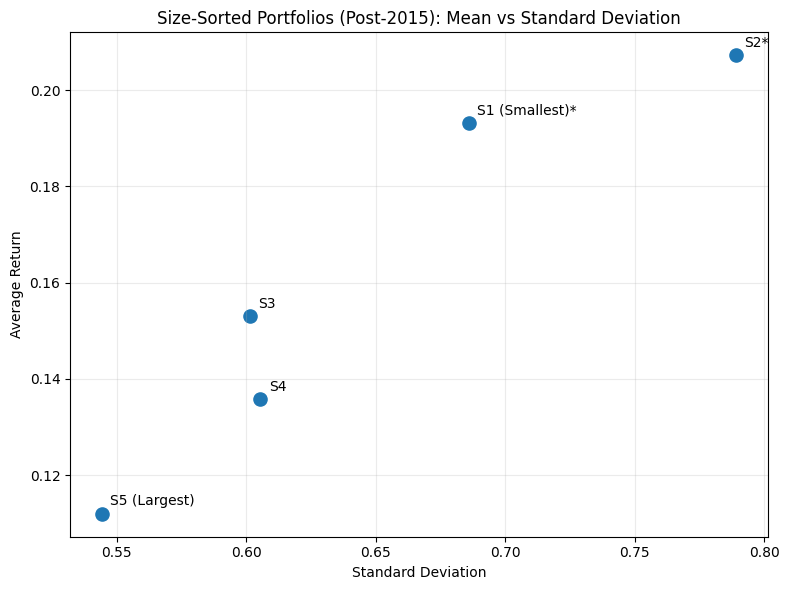

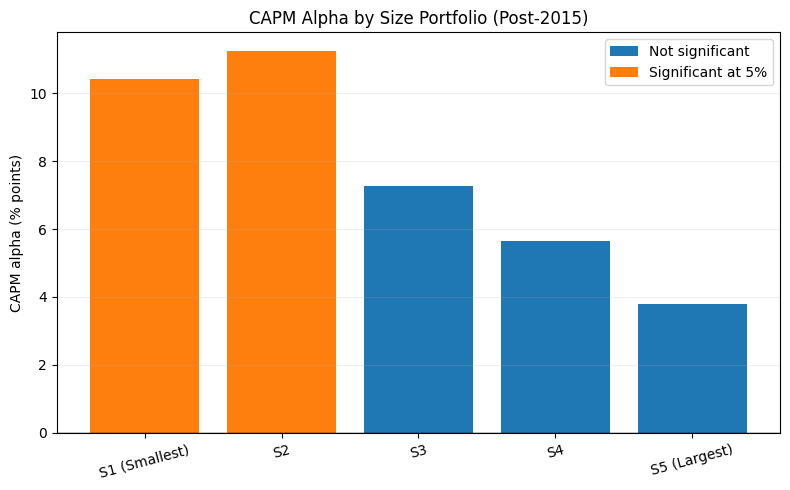

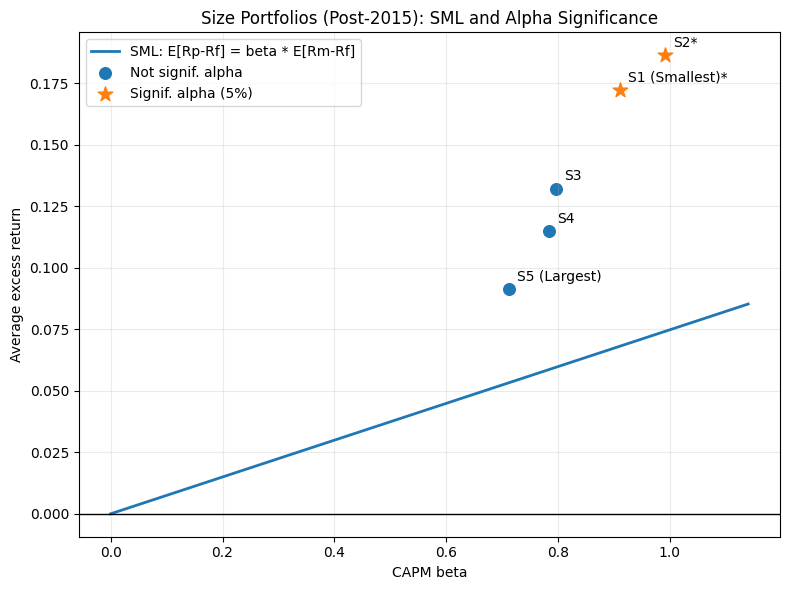

,Mean return,Std dev,alpha_pp,t(alpha),p(alpha),Signif_5%,beta,R2
S1 (Smallest),0.1932,0.6859,10.43,2.48,0.0146,Yes,0.910,0.565
S2,0.2072,0.7892,11.23,2.17,0.0317,Yes,0.991,0.506
S3,0.1530,0.6013,7.26,1.95,0.0532,No,0.796,0.561
S4,0.1357,0.6054,5.64,1.48,0.1426,No,0.784,0.539
S5 (Largest),0.1120,0.5442,3.79,1.12,0.2643,No,0.712,0.552


In [36]:
rets = pd.read_excel("project Stocks_2026.xlsx", sheet_name="return")
mcap = pd.read_excel("project Stocks_2026.xlsx", sheet_name="Market cap")
f = pd.read_excel("project Factors_2026.xlsx")

f[["rf","rm_rf","smb_vw","hml_vw"]] = f[["rf","rm_rf","smb_vw","hml_vw"]] * 12
rets.iloc[:,3:] = rets.iloc[:,3:] * 12

f = f.rename(columns={"year":"Year","month":"Month"})
fac = f[["Year","Month","rf","rm_rf"]].copy()

rets = rets[rets["Year"] >= 2016].copy()
mcap = mcap[mcap["Year"] >= 2016].copy()

stock_cols = rets.columns[3:]

rows = []
membership_rows = []

for yr in sorted(rets["Year"].unique()):
    R_y = rets[rets["Year"] == yr].copy()
    C_y = mcap[mcap["Year"] == yr].copy()

    if R_y.empty or C_y.empty:
        continue

    C_jan = C_y[C_y["Month"] == 1]
    cap0_row = (C_jan.iloc[0] if not C_jan.empty else C_y.sort_values("Month").iloc[0])

    cap0 = pd.to_numeric(cap0_row[stock_cols], errors="coerce").dropna()
    if len(cap0) < 5:
        continue

    ranks = cap0.rank(method="first")
    groups = pd.qcut(ranks, 5, labels=[1,2,3,4,5])

    for k in [1,2,3,4,5]:
        members = list(groups.index[groups == k])
        membership_rows.append({
            "Year": yr,
            "Portfolio": f"S{k}",
            "N_stocks": len(members),
            "Avg_start_cap": cap0.loc[members].mean()
        })

    for _, r in R_y.iterrows():
        for k in [1,2,3,4,5]:
            members = list(groups.index[groups == k])
            ret_k = pd.to_numeric(r[members], errors="coerce").mean(skipna=True)
            rows.append({
                "Year": int(r["Year"]),
                "Month": int(r["Month"]),
                "Portfolio": f"S{k}",
                "ret": ret_k
            })

ports = pd.DataFrame(rows)
membership = pd.DataFrame(membership_rows)

portfolio_labels = {
    "S1": "S1 (Smallest)",
    "S2": "S2",
    "S3": "S3",
    "S4": "S4",
    "S5": "S5 (Largest)"
}

ports = ports.merge(fac, on=["Year","Month"], how="inner")
ports["excess"] = ports["ret"] - ports["rf"]

stats4 = ports.groupby("Portfolio")["ret"].agg(["mean","std","min","max","count"]).reindex(["S1","S2","S3","S4","S5"])
stats4.columns = ["Mean return","Std dev","Min","Max","N months"]

stats4_show = stats4.copy()
stats4_show.index = [portfolio_labels.get(i, i) for i in stats4_show.index]
display(stats4_show.style.format("{:.4f}"))

alpha_rows = []
for p in ["S1","S2","S3","S4","S5"]:
    dfp = ports[ports["Portfolio"] == p].dropna(subset=["excess","rm_rf"]).copy()
    fit = sm.OLS(dfp["excess"], sm.add_constant(dfp["rm_rf"])).fit()

    alpha_rows.append({
        "Portfolio": p,
        "alpha": fit.params.get("const", np.nan),
        "alpha_pp": 100 * fit.params.get("const", np.nan),
        "t(alpha)": fit.tvalues.get("const", np.nan),
        "p(alpha)": fit.pvalues.get("const", np.nan),
        "Signif_5%": "Yes" if fit.pvalues.get("const", np.nan) < 0.05 else "No",
        "beta": fit.params.get("rm_rf", np.nan),
        "R2": fit.rsquared,
        "N": int(fit.nobs)
    })

alpha4 = pd.DataFrame(alpha_rows).set_index("Portfolio").reindex(["S1","S2","S3","S4","S5"])

alpha4_show = alpha4.copy()
alpha4_show.index = [portfolio_labels.get(i, i) for i in alpha4_show.index]
display(alpha4_show.style.format({
    "alpha": "{:.4f}",
    "alpha_pp": "{:.2f}",
    "t(alpha)": "{:.2f}",
    "p(alpha)": "{:.4f}",
    "beta": "{:.3f}",
    "R2": "{:.3f}"
}))

membership_summary = membership.groupby("Portfolio").agg({
    "N_stocks": ["mean","min","max"],
    "Avg_start_cap": "mean"
}).reindex(["S1","S2","S3","S4","S5"])
membership_summary.columns = ["Avg N stocks","Min N stocks","Max N stocks","Avg start-year mcap"]

membership_summary_show = membership_summary.copy()
membership_summary_show.index = [portfolio_labels.get(i, i) for i in membership_summary_show.index]
display(membership_summary_show.style.format("{:.2f}"))

plot_df = stats4.join(alpha4[["alpha_pp","t(alpha)","p(alpha)","beta"]])

plt.figure(figsize=(8,6))
plt.scatter(plot_df["Std dev"], plot_df["Mean return"], s=90)

for p in ["S1","S2","S3","S4","S5"]:
    if p in plot_df.index:
        star = "*" if plot_df.loc[p, "p(alpha)"] < 0.05 else ""
        label = portfolio_labels.get(p, p) + star
        plt.annotate(label, (plot_df.loc[p, "Std dev"], plot_df.loc[p, "Mean return"]),
                     textcoords="offset points", xytext=(6,6))

plt.xlabel("Standard Deviation")
plt.ylabel("Average Return")
plt.title("Size-Sorted Portfolios (Post-2015): Mean vs Standard Deviation")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sig = alpha4["p(alpha)"] < 0.05
x_pos = np.arange(len(alpha4.index))

plt.bar(x_pos[~sig.values], alpha4.loc[~sig, "alpha_pp"], label="Not significant")
plt.bar(x_pos[sig.values], alpha4.loc[sig, "alpha_pp"], label="Significant at 5%")
plt.axhline(0, linewidth=1, color="black")
plt.xticks(x_pos, [portfolio_labels.get(i, i) for i in alpha4.index], rotation=15)
plt.ylabel("CAPM alpha (% points)")
plt.title("CAPM Alpha by Size Portfolio (Post-2015)")
plt.grid(True, axis="y", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

reg_plot = ports.groupby("Portfolio")["excess"].mean().to_frame("mean_excess").join(alpha4[["beta","p(alpha)"]]).reindex(["S1","S2","S3","S4","S5"])
mu_mkt = ports["rm_rf"].mean()

x = np.linspace(0, max(reg_plot["beta"].max()*1.15, 0.1), 100)
sml = mu_mkt * x

plt.figure(figsize=(8,6))
plt.plot(x, sml, linewidth=2, label="SML: E[Rp-Rf] = beta * E[Rm-Rf]")

sig = reg_plot["p(alpha)"] < 0.05
plt.scatter(reg_plot.loc[~sig, "beta"], reg_plot.loc[~sig, "mean_excess"], s=70, label="Not signif. alpha")
plt.scatter(reg_plot.loc[sig, "beta"], reg_plot.loc[sig, "mean_excess"], s=120, marker="*", label="Signif. alpha (5%)")

for idx, row in reg_plot.iterrows():
    star = "*" if row["p(alpha)"] < 0.05 else ""
    label = portfolio_labels.get(idx, idx) + star
    plt.annotate(label, (row["beta"], row["mean_excess"]),
                 textcoords="offset points", xytext=(6,6))

plt.axhline(0, linewidth=1, color="black")
plt.xlabel("CAPM beta")
plt.ylabel("Average excess return")
plt.title("Size Portfolios (Post-2015): SML and Alpha Significance")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

output4 = stats4[["Mean return","Std dev"]].join(alpha4[["alpha_pp","t(alpha)","p(alpha)","Signif_5%","beta","R2"]]).reindex(["S1","S2","S3","S4","S5"])
output4_show = output4.copy()
output4_show.index = [portfolio_labels.get(i, i) for i in output4_show.index]

display(output4_show.style.format({
    "Mean return": "{:.4f}",
    "Std dev": "{:.4f}",
    "alpha_pp": "{:.2f}",
    "t(alpha)": "{:.2f}",
    "p(alpha)": "{:.4f}",
    "beta": "{:.3f}",
    "R2": "{:.3f}"
}))

5.)

,net_alpha,net_alpha_pp,net_t_alpha,net_p_alpha,net_signif_5%,net_beta,net_R2,net_N
Fund,,,,,,,,
Swedbank Robur Exportfond A,0.0731,7.31,2.49,0.0135,Yes,0.584,0.370,264
Aktiespararna Topp Sverige Hållbar A,0.0636,6.36,2.65,0.0086,Yes,0.591,0.473,264
Swedbank Robur Småbolagsfond Sverige A,0.0470,4.70,1.62,0.1073,No,0.652,0.427,264
Öhman Sweden Micro Cap A,0.0422,4.22,1.44,0.1514,No,0.679,0.451,258
SEB Sweden Equity C,0.0373,3.73,1.52,0.1293,No,0.611,0.480,264
Storebrand Sverige A SEK,0.0298,2.98,1.22,0.2253,No,0.590,0.462,264
Swedbank Robur Sverige A,0.0214,2.14,0.74,0.4616,No,0.670,0.440,264
Enter Sverige Hållbar Tillväxt A,0.0202,2.02,0.81,0.4195,No,0.661,0.510,264
AMF Aktiefond Sverige,0.0148,1.48,0.59,0.5555,No,0.593,0.453,264


,gross_alpha,gross_alpha_pp,gap_gross_minus_net,gap_gross_minus_net_pp,gross_p_alpha,net_alpha,net_p_alpha
Fund,,,,,,,
Swedbank Robur Exportfond A,0.0850,8.50,0.0119,1.19,0.0042,0.0731,0.0135
Swedbank Robur Småbolagsfond Sverige A,0.0577,5.77,0.0107,1.07,0.0489,0.0470,0.1073
AMF Aktiefond Småbolag,0.0219,2.19,0.0107,1.07,0.4135,0.0112,0.6752
Enter Sverige Hållbar Tillväxt A,0.0309,3.09,0.0107,1.07,0.2185,0.0202,0.4195
Swedbank Robur Sverige A,0.0321,3.21,0.0107,1.07,0.2714,0.0214,0.4616
Aktiespararna Topp Sverige Hållbar A,0.0698,6.98,0.0061,0.61,0.0040,0.0636,0.0086
Öhman Sweden Micro Cap A,0.0468,4.68,0.0045,0.45,0.1129,0.0422,0.1514
SEB Sweden Equity C,0.0405,4.05,0.0032,0.32,0.0998,0.0373,0.1293
AMF Aktiefond Sverige,0.0172,1.72,0.0024,0.24,0.4934,0.0148,0.5555


,Metric,Value
0,N funds,10.0000
1,Avg net alpha,0.0361
2,Avg gross alpha,0.0433
3,Avg gap (gross-net),0.0073
4,Median net alpha,0.0335
5,Median gross alpha,0.0363
6,Median gap (gross-net),0.0084
7,Share net alpha signif 5%,0.2000
8,Share gross alpha signif 5%,0.3000


,n_funds,avg_net_alpha,avg_gross_alpha,avg_gap,med_net_alpha,med_gross_alpha,med_gap,share_net_signif_5,share_gross_signif_5
fund type,,,,,,,,,
actively managed equity fund,8,0.0334,0.0415,0.0081,0.0294,0.0363,0.0107,12.50%,25.00%
index-based equity fund,1,0.0298,0.0314,0.0016,0.0298,0.0314,0.0016,0.00%,0.00%
passively managed equity fund,1,0.0636,0.0698,0.0061,0.0636,0.0698,0.0061,100.00%,100.00%


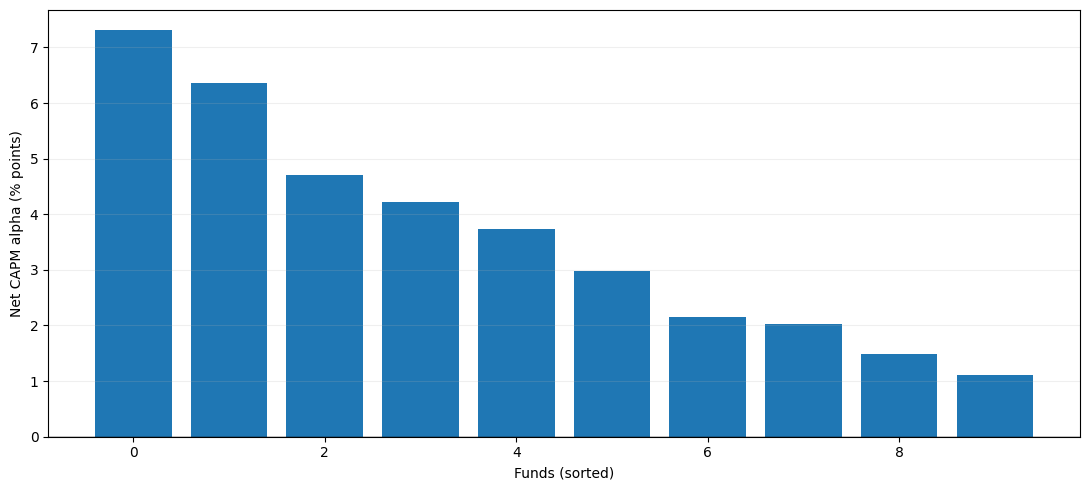

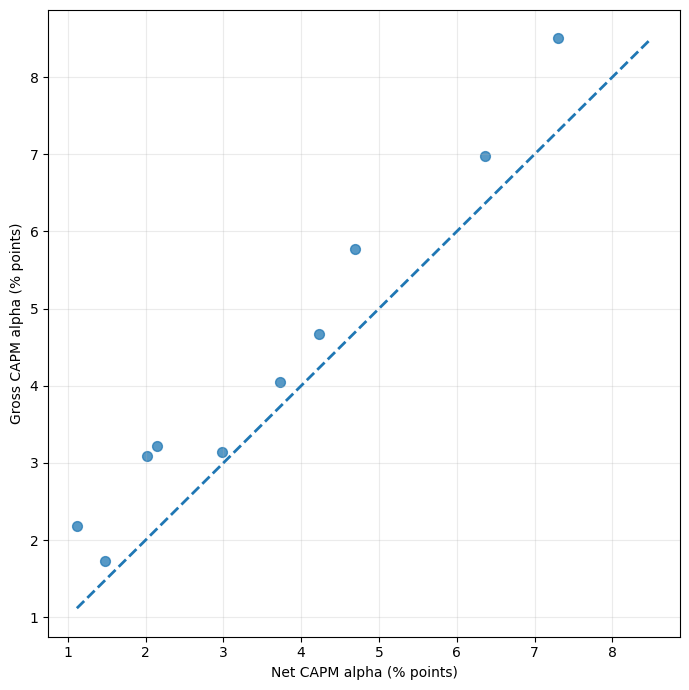

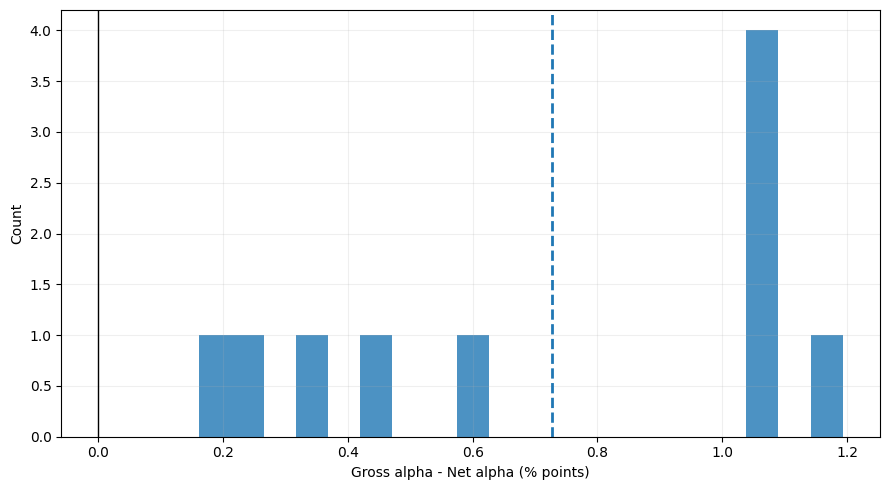

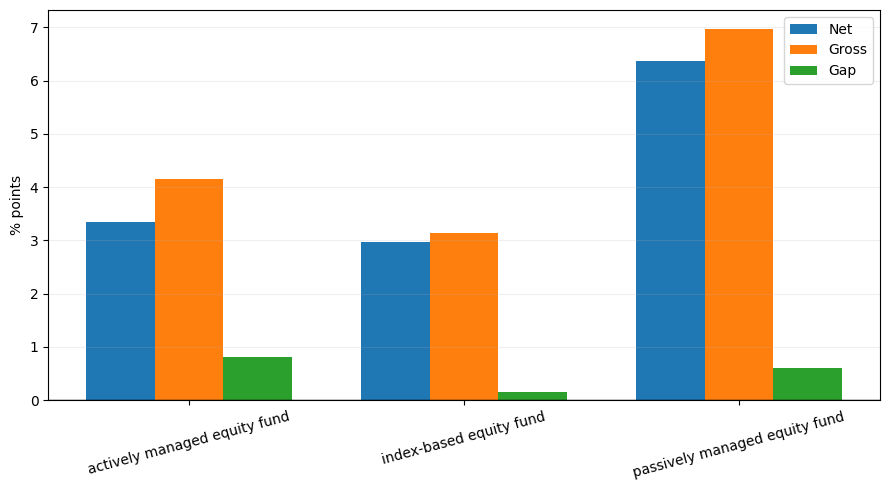

In [39]:
fund_net   = pd.read_excel("project Funds_2026.xlsx", sheet_name="Net")
fund_gross = pd.read_excel("project Funds_2026.xlsx", sheet_name="Gross")
info       = pd.read_excel("project Funds_2026.xlsx", sheet_name="Info")
f          = pd.read_excel("project Factors_2026.xlsx")

f[["rf","rm_rf","smb_vw","hml_vw"]] *= 12
fund_net.iloc[:,3:]   *= 12
fund_gross.iloc[:,3:] *= 12

f = f.rename(columns={"year":"Year","month":"Month"})
fac = f[["Year","Month","rf","rm_rf"]].copy()

net   = fund_net.merge(fac, on=["Year","Month"], how="inner")
gross = fund_gross.merge(fac, on=["Year","Month"], how="inner")

fund_cols = fund_net.columns[3:]

def capm_alpha_table(df, cols):
    rows = []
    X_all = sm.add_constant(df["rm_rf"])
    for c in cols:
        y = pd.to_numeric(df[c], errors="coerce") - pd.to_numeric(df["rf"], errors="coerce")
        fit = sm.OLS(y, X_all, missing="drop").fit()
        rows.append({
            "Fund": c,
            "alpha": fit.params.get("const", np.nan),
            "alpha_pp": 100 * fit.params.get("const", np.nan),
            "t_alpha": fit.tvalues.get("const", np.nan),
            "p_alpha": fit.pvalues.get("const", np.nan),
            "signif_5%": "Yes" if fit.pvalues.get("const", np.nan) < 0.05 else "No",
            "beta": fit.params.get("rm_rf", np.nan),
            "R2": fit.rsquared,
            "N": int(fit.nobs)
        })
    return pd.DataFrame(rows).set_index("Fund")

alpha_net   = capm_alpha_table(net, fund_cols).add_prefix("net_")
alpha_gross = capm_alpha_table(gross, fund_cols).add_prefix("gross_")

results = pd.concat([alpha_net, alpha_gross], axis=1)
results["gap_gross_minus_net"] = results["gross_alpha"] - results["net_alpha"]
results["gap_gross_minus_net_pp"] = 100 * results["gap_gross_minus_net"]

info_cols_lower = {c.lower(): c for c in info.columns}
name_col = None
type_col = None

for cand in ["fund name", "fund_name", "name"]:
    if cand in info_cols_lower:
        name_col = info_cols_lower[cand]
        break

for cand in ["fund type", "fund_type", "type"]:
    if cand in info_cols_lower:
        type_col = info_cols_lower[cand]
        break

if name_col is not None:
    add_cols = [name_col]
    if type_col is not None:
        add_cols.append(type_col)
    info_map = info[add_cols].copy().drop_duplicates(subset=[name_col]).set_index(name_col)
    results = results.join(info_map, how="left")

if type_col is not None and type_col in results.columns:
    results[type_col] = results[type_col].astype(str).str.strip()

display(
    results[["net_alpha","net_alpha_pp","net_t_alpha","net_p_alpha","net_signif_5%","net_beta","net_R2","net_N"]]
    .sort_values("net_alpha", ascending=False)
    .style.format({
        "net_alpha": "{:.4f}",
        "net_alpha_pp": "{:.2f}",
        "net_t_alpha": "{:.2f}",
        "net_p_alpha": "{:.4f}",
        "net_beta": "{:.3f}",
        "net_R2": "{:.3f}"
    })
)

display(
    results[[
        "gross_alpha","gross_alpha_pp","gap_gross_minus_net","gap_gross_minus_net_pp",
        "gross_p_alpha","net_alpha","net_p_alpha"
    ]]
    .sort_values("gap_gross_minus_net", ascending=False)
    .style.format({
        "gross_alpha": "{:.4f}",
        "gross_alpha_pp": "{:.2f}",
        "gap_gross_minus_net": "{:.4f}",
        "gap_gross_minus_net_pp": "{:.2f}",
        "gross_p_alpha": "{:.4f}",
        "net_alpha": "{:.4f}",
        "net_p_alpha": "{:.4f}"
    })
)

summary_all = pd.DataFrame({
    "Metric": [
        "N funds",
        "Avg net alpha",
        "Avg gross alpha",
        "Avg gap (gross-net)",
        "Median net alpha",
        "Median gross alpha",
        "Median gap (gross-net)",
        "Share net alpha signif 5%",
        "Share gross alpha signif 5%"
    ],
    "Value": [
        len(results),
        results["net_alpha"].mean(),
        results["gross_alpha"].mean(),
        results["gap_gross_minus_net"].mean(),
        results["net_alpha"].median(),
        results["gross_alpha"].median(),
        results["gap_gross_minus_net"].median(),
        (results["net_p_alpha"] < 0.05).mean(),
        (results["gross_p_alpha"] < 0.05).mean()
    ]
})
display(summary_all.style.format({"Value": "{:.4f}"}))

if type_col is not None and type_col in results.columns:
    group_summary = results.groupby(type_col).agg(
        n_funds=("net_alpha", "size"),
        avg_net_alpha=("net_alpha", "mean"),
        avg_gross_alpha=("gross_alpha", "mean"),
        avg_gap=("gap_gross_minus_net", "mean"),
        med_net_alpha=("net_alpha", "median"),
        med_gross_alpha=("gross_alpha", "median"),
        med_gap=("gap_gross_minus_net", "median"),
        share_net_signif_5=("net_p_alpha", lambda x: (x < 0.05).mean()),
        share_gross_signif_5=("gross_p_alpha", lambda x: (x < 0.05).mean())
    )

    display(group_summary.style.format({
        "avg_net_alpha": "{:.4f}",
        "avg_gross_alpha": "{:.4f}",
        "avg_gap": "{:.4f}",
        "med_net_alpha": "{:.4f}",
        "med_gross_alpha": "{:.4f}",
        "med_gap": "{:.4f}",
        "share_net_signif_5": "{:.2%}",
        "share_gross_signif_5": "{:.2%}"
    }))

plot_net = results.sort_values("net_alpha", ascending=False)

plt.figure(figsize=(11,5))
plt.bar(np.arange(len(plot_net)), 100 * plot_net["net_alpha"])
plt.axhline(0, linewidth=1, color="black")
plt.xlabel("Funds (sorted)")
plt.ylabel("Net CAPM alpha (% points)")
plt.grid(True, axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,7))
plt.scatter(100 * results["net_alpha"], 100 * results["gross_alpha"], s=50, alpha=0.75)
xy_min = min((100 * results["net_alpha"]).min(), (100 * results["gross_alpha"]).min())
xy_max = max((100 * results["net_alpha"]).max(), (100 * results["gross_alpha"]).max())
plt.plot([xy_min, xy_max], [xy_min, xy_max], linestyle="--", linewidth=2)
plt.xlabel("Net CAPM alpha (% points)")
plt.ylabel("Gross CAPM alpha (% points)")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,5))
plt.hist(100 * results["gap_gross_minus_net"].dropna(), bins=20, alpha=0.8)
plt.axvline(0, linewidth=1, color="black")
plt.axvline(100 * results["gap_gross_minus_net"].mean(), linestyle="--", linewidth=2)
plt.xlabel("Gross alpha - Net alpha (% points)")
plt.ylabel("Count")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

if type_col is not None and type_col in results.columns:
    grp = results.groupby(type_col)[["net_alpha","gross_alpha","gap_gross_minus_net"]].mean() * 100

    plt.figure(figsize=(9,5))
    x = np.arange(len(grp.index))
    w = 0.25
    plt.bar(x - w, grp["net_alpha"], width=w, label="Net")
    plt.bar(x, grp["gross_alpha"], width=w, label="Gross")
    plt.bar(x + w, grp["gap_gross_minus_net"], width=w, label="Gap")
    plt.axhline(0, linewidth=1, color="black")
    plt.xticks(x, grp.index, rotation=15)
    plt.ylabel("% points")
    plt.grid(True, axis="y", alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()

6.)

,alpha,alpha_pp,beta,sig2_eps,score,w_active,final_weight
Asset,,,,,,,
Volvo AB A,0.086606,8.6606,1.0174,0.633278,0.136758,0.205017,0.358272
Assa Abloy AB B,0.089246,8.9246,0.5853,0.501144,0.178085,0.266972,0.466539
Handelsbanken AB A,0.066690,6.6690,0.6065,0.405457,0.164481,0.246578,0.430899
Industrivarden AB A,0.062687,6.2687,0.8579,0.333920,0.187731,0.281433,0.491810


,Weight
Market,-0.7475199248
Volvo AB A,0.3582716670
Assa Abloy AB B,0.4665386660
Handelsbanken AB A,0.4308994023
Industrivarden AB A,0.4918101895


,Value
Sum final weights,1.0000000000
Market weight,-0.7475199248
Active sleeve weight,1.7475199248
Sum active weights (within A),1.0000000000
Active beta,0.7558342155
Final portfolio beta,0.5733154266
Active alpha,0.0756684058
Final portfolio alpha,0.1322320469


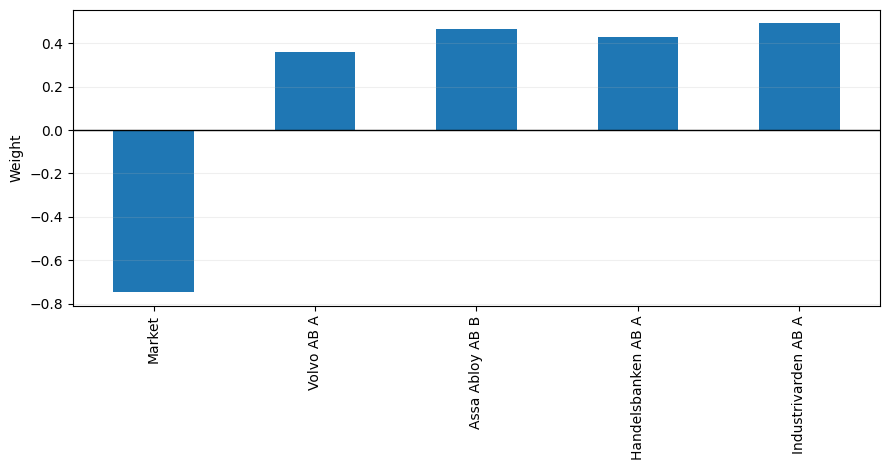

In [40]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

names = ["Volvo AB A", "Assa Abloy AB B", "Handelsbanken AB A", "Industrivarden AB A"]

rets = pd.read_excel("project Stocks_2026.xlsx", sheet_name="return")
f = pd.read_excel("project Factors_2026.xlsx")

f[["rf","rm_rf","smb_vw","hml_vw"]] *= 12
rets.iloc[:,3:] *= 12

f = f.rename(columns={"year":"Year","month":"Month"})
data = rets.merge(f[["Year","Month","rf","rm_rf"]], on=["Year","Month"], how="inner")

Rm = pd.to_numeric(data["rm_rf"], errors="coerce")
Rf = pd.to_numeric(data["rf"], errors="coerce")
mu_Rm = Rm.mean()
var_Rm = Rm.var()

rows = []
for s in names:
    Ri = pd.to_numeric(data[s], errors="coerce") - Rf
    fit = sm.OLS(Ri, sm.add_constant(Rm), missing="drop").fit()
    rows.append({
        "Asset": s,
        "alpha": fit.params.get("const", np.nan),
        "beta": fit.params.get("rm_rf", np.nan),
        "sig2_eps": np.var(fit.resid, ddof=1)
    })

est = pd.DataFrame(rows).set_index("Asset")

est["score"] = est["alpha"] / est["sig2_eps"]
est["w_active"] = est["score"] / est["score"].sum()

alpha_A = (est["w_active"] * est["alpha"]).sum()
beta_A  = (est["w_active"] * est["beta"]).sum()
sig2e_A = ((est["w_active"]**2) * est["sig2_eps"]).sum()

wA0 = (alpha_A / sig2e_A) / (mu_Rm / var_Rm)
wA_star = wA0 / (1 + (1 - beta_A) * wA0)
wM_star = 1 - wA_star

est["final_weight"] = wA_star * est["w_active"]

weights_table = pd.DataFrame(
    {"Weight": [wM_star] + [est.loc[s, "final_weight"] for s in names]},
    index=["Market"] + names
)

output = est[["alpha","beta","sig2_eps","score","w_active","final_weight"]].copy()
output["alpha_pp"] = 100 * output["alpha"]
output = output[["alpha","alpha_pp","beta","sig2_eps","score","w_active","final_weight"]]

display(output.style.format({
    "alpha": "{:.6f}",
    "alpha_pp": "{:.4f}",
    "beta": "{:.4f}",
    "sig2_eps": "{:.6f}",
    "score": "{:.6f}",
    "w_active": "{:.6f}",
    "final_weight": "{:.6f}"
}))

display(weights_table.style.format({"Weight": "{:.10f}"}))

checks = pd.DataFrame({
    "Value": [
        weights_table["Weight"].sum(),
        wM_star,
        wA_star,
        est["w_active"].sum(),
        beta_A,
        wM_star + (est["final_weight"] * est["beta"]).sum(),
        alpha_A,
        (est["final_weight"] * est["alpha"]).sum()
    ]
}, index=[
    "Sum final weights",
    "Market weight",
    "Active sleeve weight",
    "Sum active weights (within A)",
    "Active beta",
    "Final portfolio beta",
    "Active alpha",
    "Final portfolio alpha"
])

display(checks.style.format({"Value": "{:.10f}"}))

plt.figure(figsize=(9,4.8))
weights_table["Weight"].plot(kind="bar")
plt.axhline(0, linewidth=1, color="black")
plt.ylabel("Weight")
plt.grid(True, axis="y", alpha=0.2)
plt.tight_layout()
plt.show()